In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

from scipy.stats import skew

In [11]:
df = pd.read_csv("/content/ecommerce_customer_churn_dataset.csv")

In [12]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [13]:
df.shape

(50000, 25)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [15]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [16]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

,0
Social_Media_Engagement_Score,6000
Credit_Balance,5500
Mobile_App_Usage,5000
Returns_Rate,4491
Wishlist_Items,4000
Discount_Usage_Rate,3500
Product_Reviews_Written,3500
Session_Duration_Avg,3399
Pages_Per_Session,3000
Days_Since_Last_Purchase,3000


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values('Missing Percentage', ascending=False)

missing_summary

,Missing Values,Missing Percentage
Social_Media_Engagement_Score,6000,12.000
Credit_Balance,5500,11.000
Mobile_App_Usage,5000,10.000
Returns_Rate,4491,8.982
Wishlist_Items,4000,8.000
Discount_Usage_Rate,3500,7.000
Product_Reviews_Written,3500,7.000
Session_Duration_Avg,3399,6.798
Pages_Per_Session,3000,6.000
Days_Since_Last_Purchase,3000,6.000


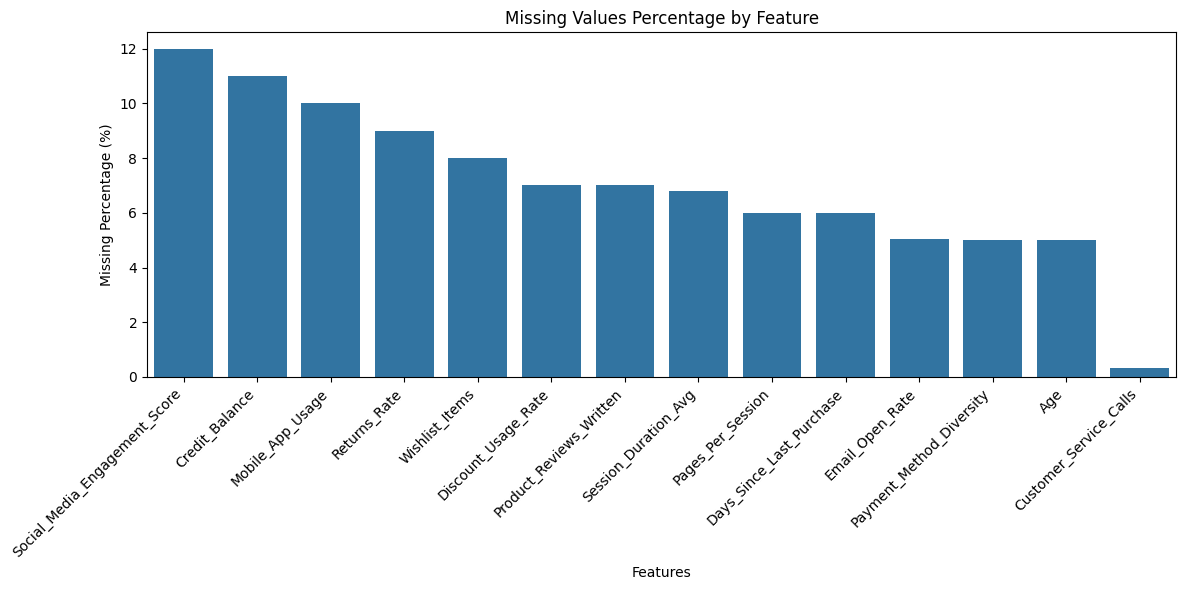

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary['Missing Percentage']
)

plt.title('Missing Values Percentage by Feature')
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
duplicates = df.duplicated().sum()
print("Number of duplicates:", duplicates)

Number of duplicates: 0


In [20]:
df.nunique().sort_values()

,0
Churned,2
Gender,3
Signup_Quarter,4
Payment_Method_Diversity,5
Country,8
Product_Reviews_Written,18
Customer_Service_Calls,21
Wishlist_Items,25
City,40
Login_Frequency,46


In [21]:
for col in df.columns:
    if df[col].nunique() <= 10:
        print(f"\n{col}:")
        print(df[col].unique())


Gender:
['Male' 'Female' 'Other']

Country:
['France' 'UK' 'Canada' 'USA' 'India' 'Japan' 'Germany' 'Australia']

Payment_Method_Diversity:
[ 1.  3. nan  4.  2.  5.]

Churned:
[0 1]

Signup_Quarter:
['Q1' 'Q4' 'Q2' 'Q3']


In [22]:
target = 'Churned'
df[target].value_counts()

,count
Churned,
0,35550
1,14450


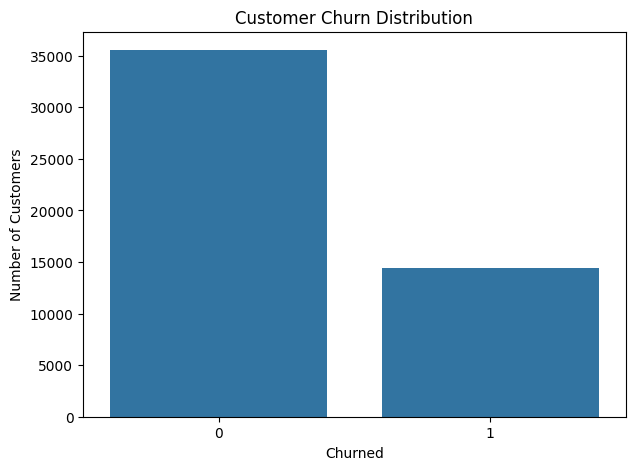

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churned')

plt.title('Customer Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Number of Customers')

plt.show()

In [24]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns

['Age',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance',
 'Churned']

In [25]:
numerical_features = [
    col for col in numerical_columns
    if col != 'Churned'
]

numerical_features

['Age',
 'Membership_Years',
 'Login_Frequency',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Cart_Abandonment_Rate',
 'Wishlist_Items',
 'Total_Purchases',
 'Average_Order_Value',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Lifetime_Value',
 'Credit_Balance']

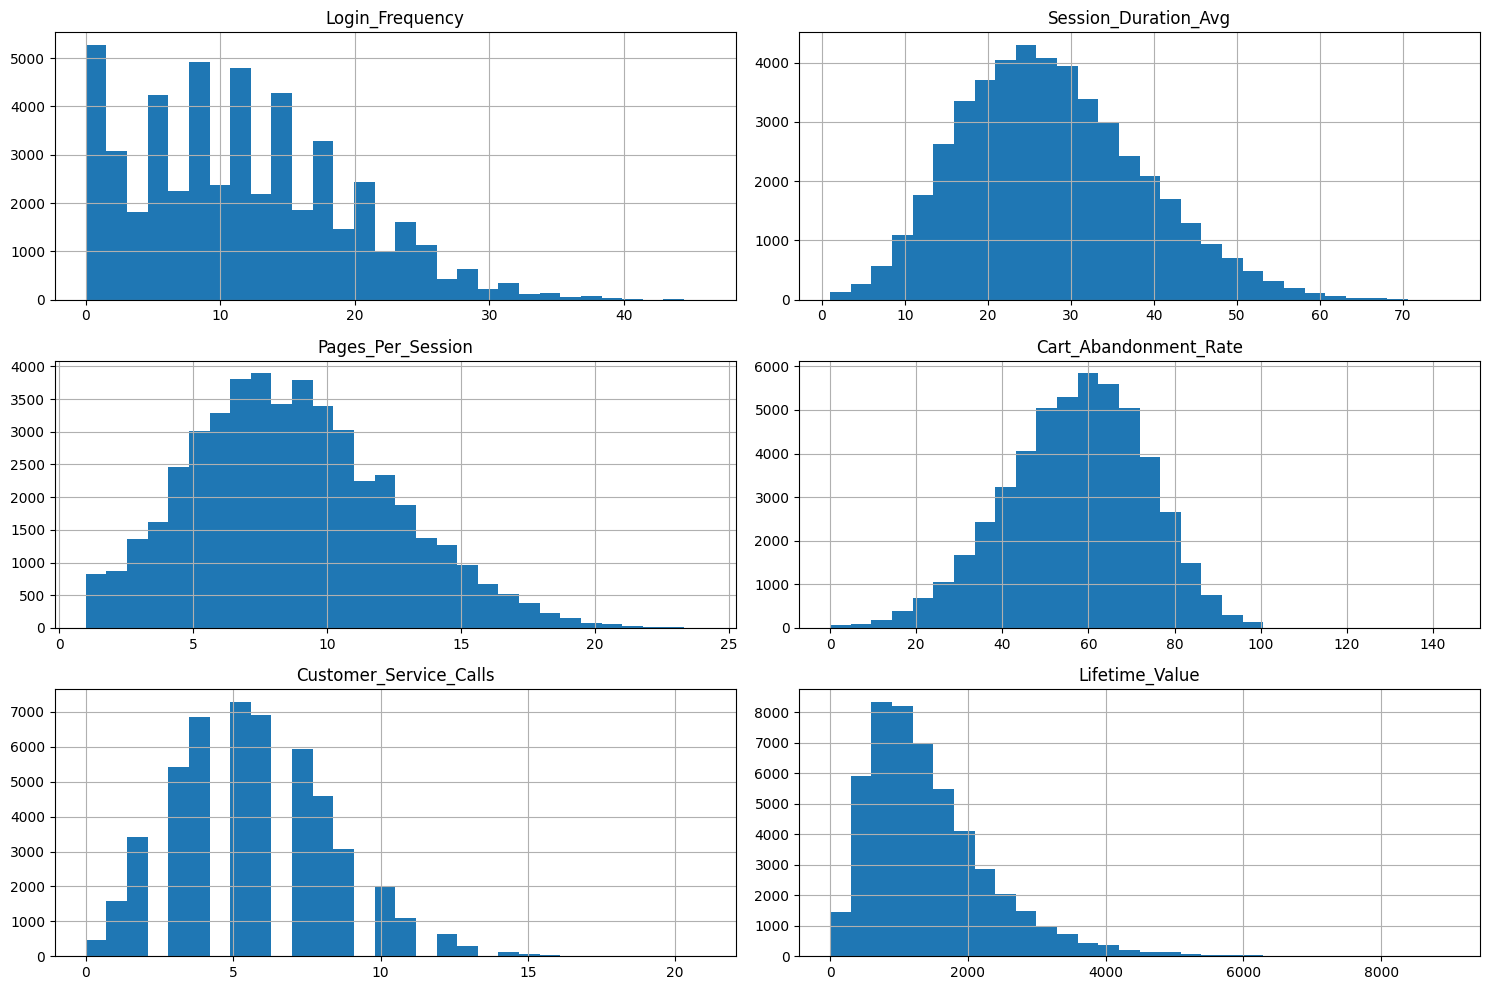

In [26]:
important_features = [
    'Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Cart_Abandonment_Rate',
    'Customer_Service_Calls',
    'Lifetime_Value'
]

df[important_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

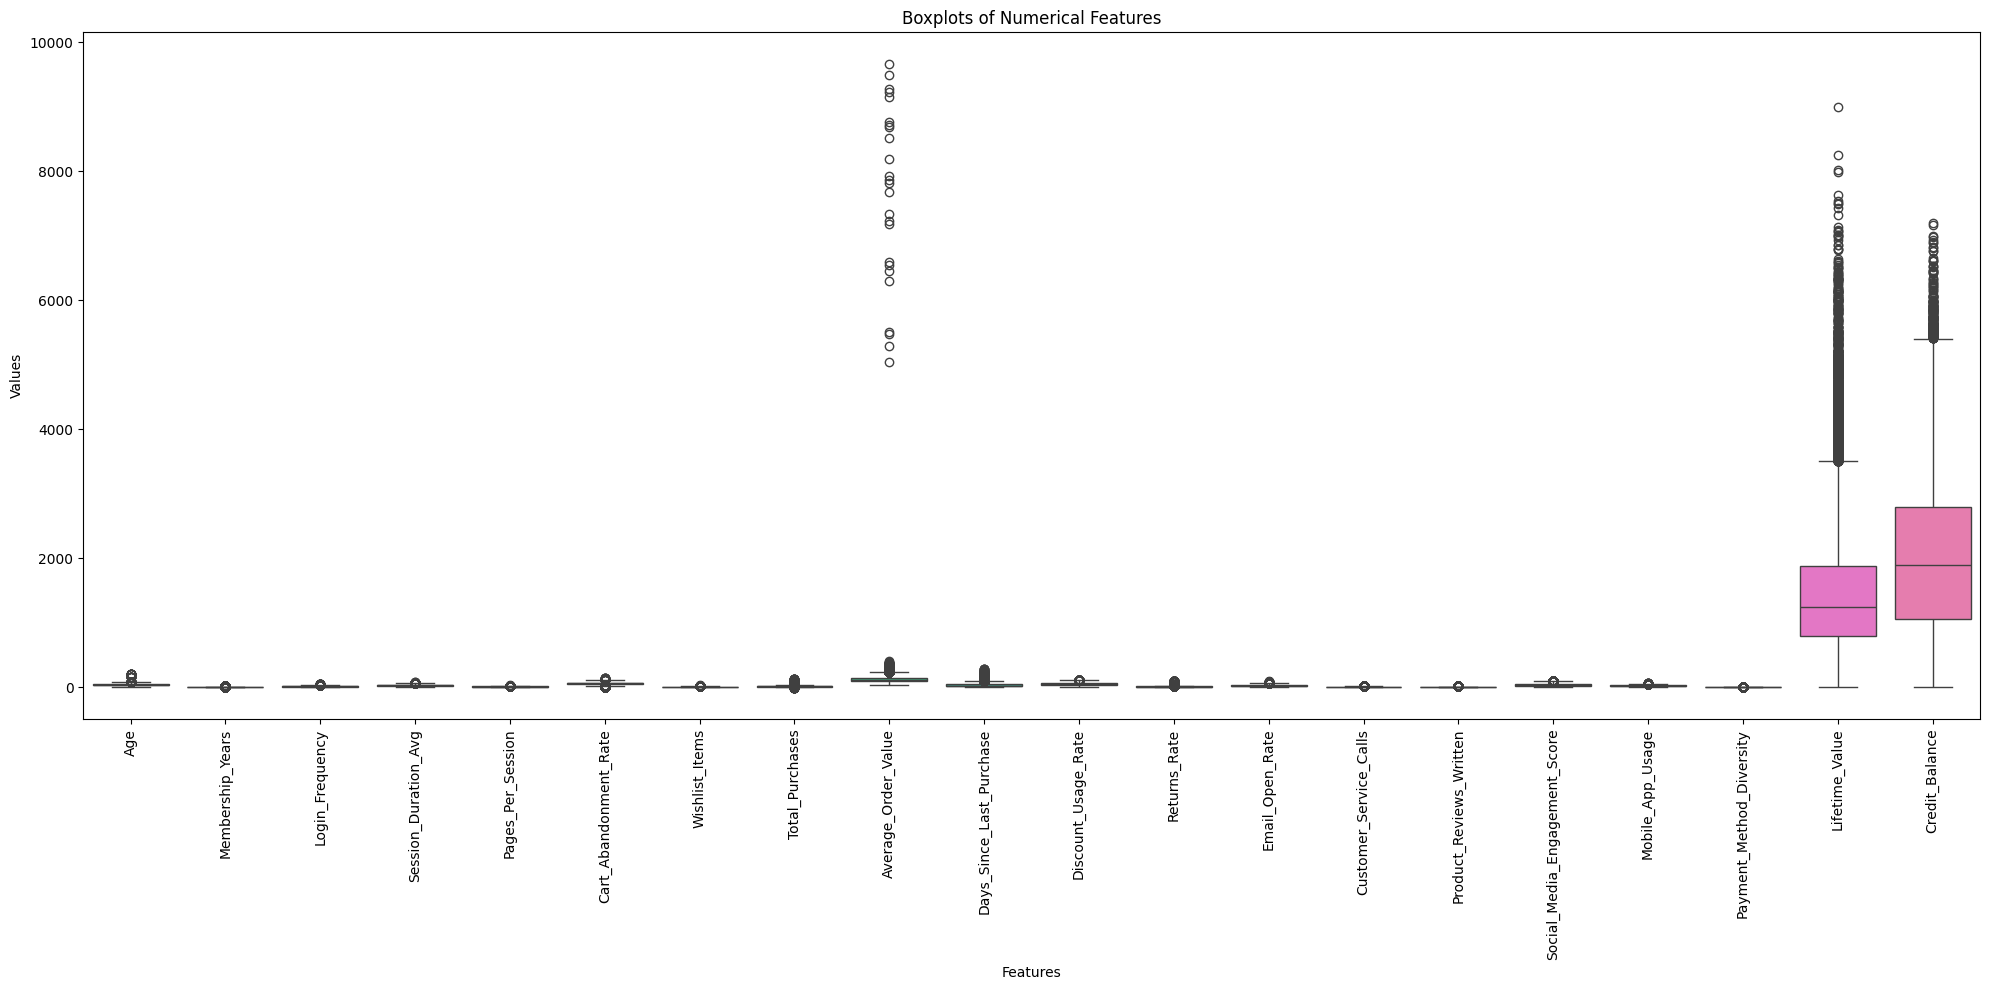

In [27]:
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df[numerical_features]
)

plt.title('Boxplots of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Values')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

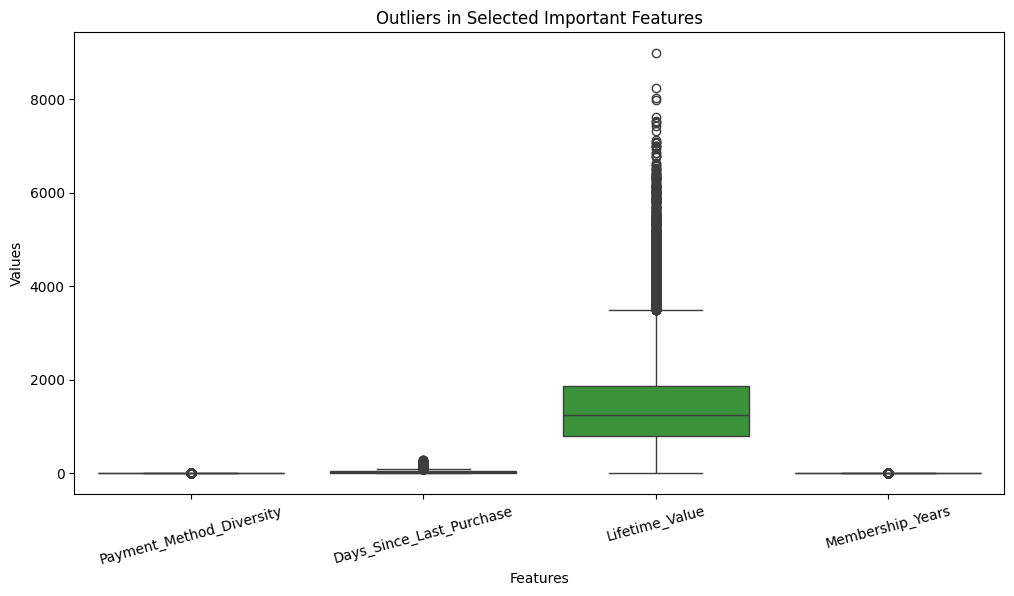

In [28]:
cols_to_check = [
    'Payment_Method_Diversity',
    'Days_Since_Last_Purchase',
    'Lifetime_Value',
    'Membership_Years'
]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[cols_to_check])

plt.title('Outliers in Selected Important Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.xticks(rotation=15)

plt.show()

In [29]:
outlier_summary = []

for col in numerical_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ][col].count()

    percentage = (outliers / df[col].notna().sum()) * 100

    outlier_summary.append({
        'Feature': col,
        'Outliers': outliers,
        'Outlier Percentage': percentage
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    'Outlier Percentage',
    ascending=False
)

,Feature,Outliers,Outlier Percentage
17,Payment_Method_Diversity,2439,5.134737
9,Days_Since_Last_Purchase,2313,4.921277
18,Lifetime_Value,1684,3.368000
1,Membership_Years,1581,3.162000
11,Returns_Rate,1204,2.645631
13,Customer_Service_Calls,1185,2.377990
14,Product_Reviews_Written,1090,2.344086
8,Average_Order_Value,1005,2.010000
6,Wishlist_Items,858,1.865217
7,Total_Purchases,628,1.256000


In [30]:
correlation_matrix = df[numerical_columns].corr()

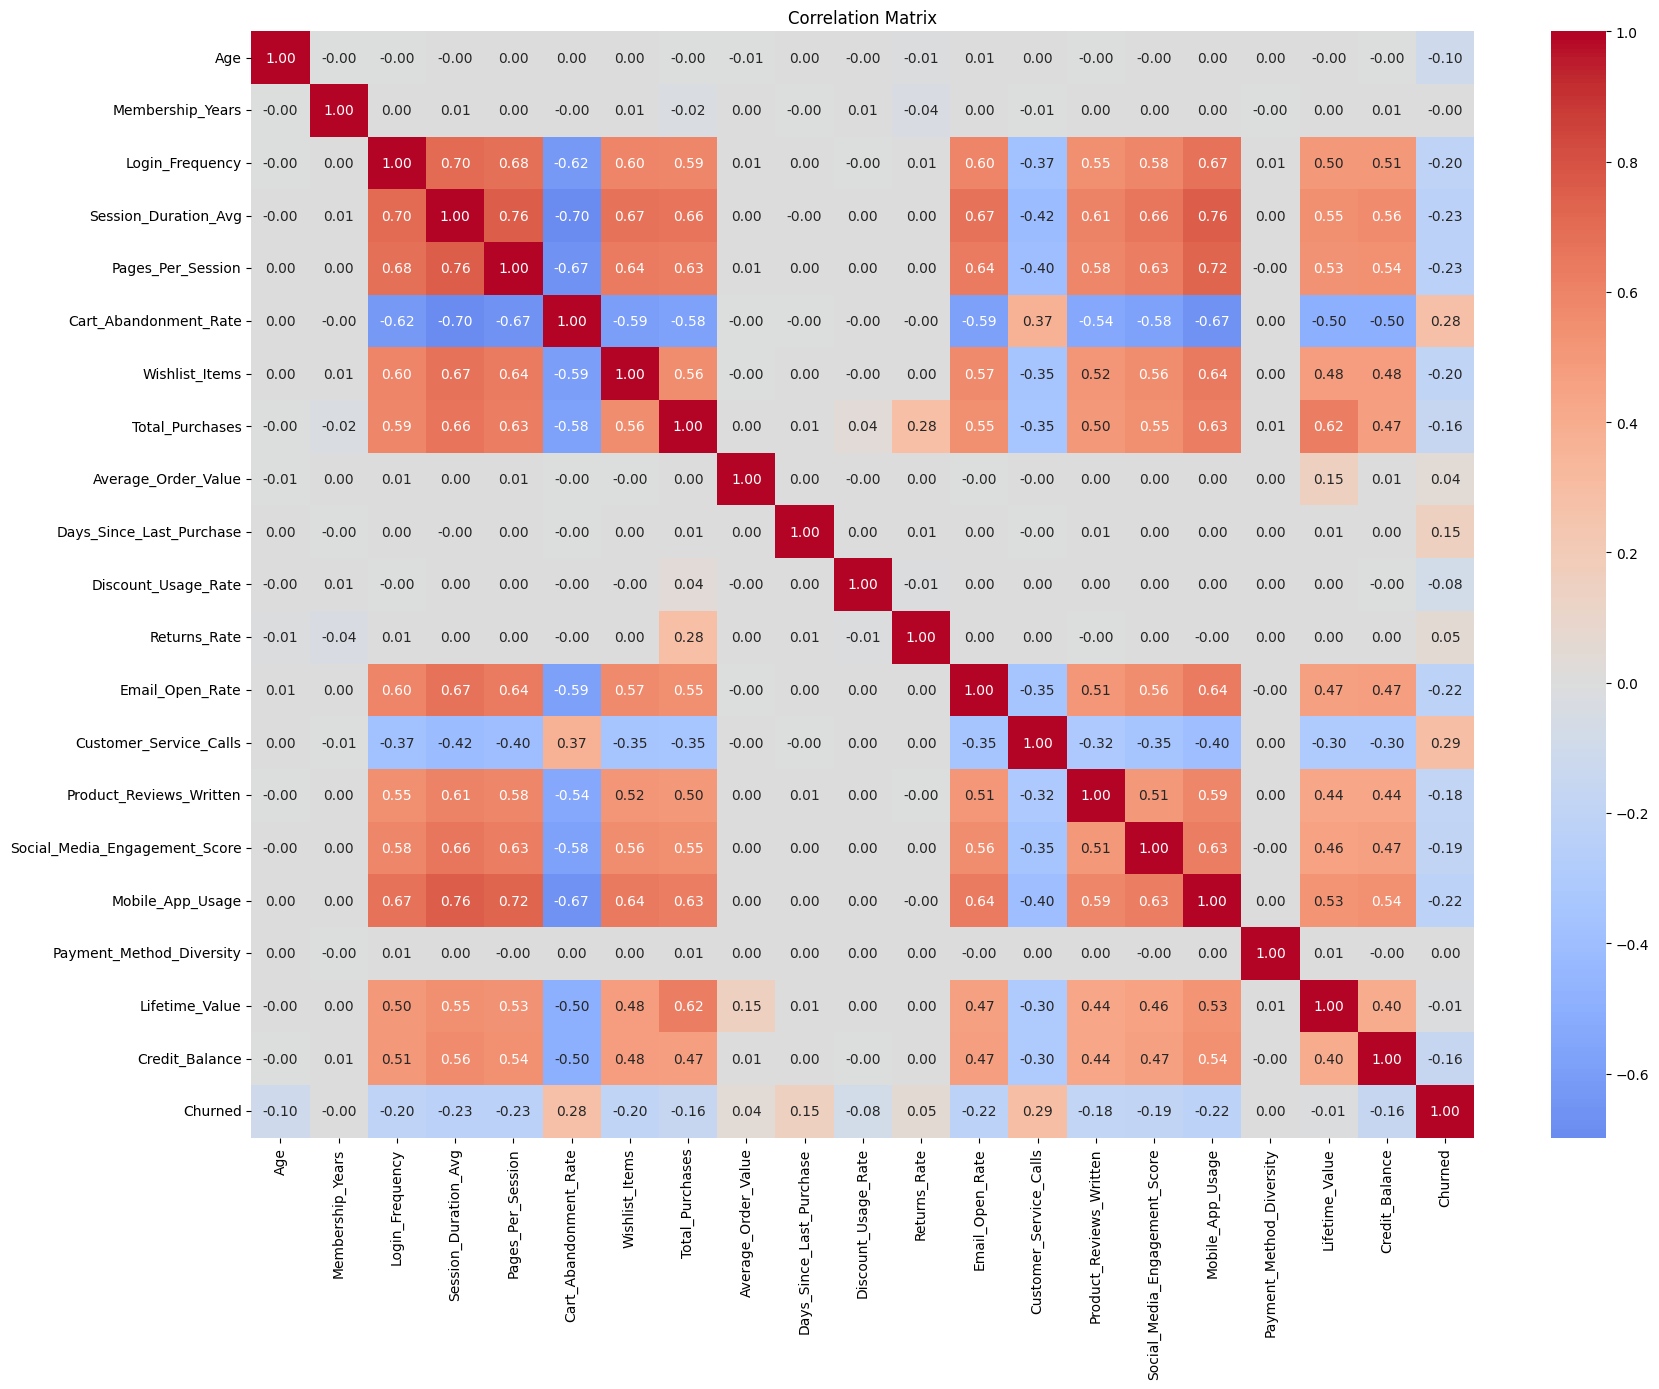

In [31]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [32]:
target_correlation = (
    correlation_matrix['Churned']
    .drop('Churned')
    .sort_values(key=abs, ascending=False)
)

target_correlation

,Churned
Customer_Service_Calls,0.291103
Cart_Abandonment_Rate,0.277963
Pages_Per_Session,-0.231799
Session_Duration_Avg,-0.228010
Mobile_App_Usage,-0.222876
Email_Open_Rate,-0.222213
Login_Frequency,-0.204379
Wishlist_Items,-0.197708
Social_Media_Engagement_Score,-0.191792
Product_Reviews_Written,-0.181225


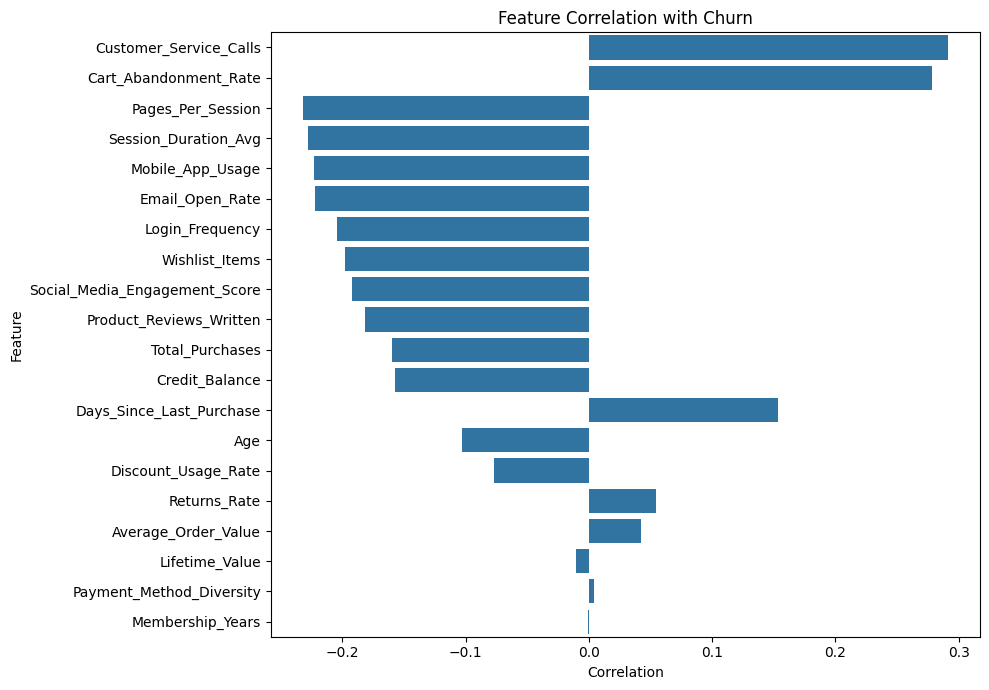

In [33]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index
)

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [34]:
corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlations = (
    corr_pairs.stack()
    .reset_index()
)

high_correlations.columns = [
    'Feature 1',
    'Feature 2',
    'Correlation'
]

high_correlations[
    high_correlations['Correlation'].abs() >= 0.7
].sort_values(
    'Correlation',
    key=abs,
    ascending=False
)

,Feature 1,Feature 2,Correlation
57,Session_Duration_Avg,Pages_Per_Session,0.756304
69,Session_Duration_Avg,Mobile_App_Usage,0.755931
85,Pages_Per_Session,Mobile_App_Usage,0.724334
39,Login_Frequency,Session_Duration_Avg,0.703510


In [35]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [36]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


In [37]:
cols_to_cap = ['Payment_Method_Diversity', 'Days_Since_Last_Purchase', 'Lifetime_Value', 'Membership_Years']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [38]:
absolute_lower = 0
absolute_upper = 80

stat_lower = df['Age'].quantile(0.01)
stat_upper = df['Age'].quantile(0.99)

print(f"Definitely invalid rows: {df[(df['Age'] < absolute_lower) | (df['Age'] > absolute_upper)].shape[0]} rows")
print(f"Suspicious rows: {df[(df['Age'] > stat_upper) & (df['Age'] <= absolute_upper)].shape[0]} rows")

Definitely invalid rows: 20 rows
Suspicious rows: 458 rows


In [39]:
suspicious = df[(df['Age'] > stat_upper) & (df['Age'] <= absolute_upper)]

print(suspicious['Age'].describe())
print(suspicious['Age'].value_counts().sort_index())

count    458.000000
mean      69.207424
std        2.906755
min       66.000000
25%       67.000000
50%       68.000000
75%       71.000000
max       75.000000
Name: Age, dtype: float64
Age
66.0    91
67.0    82
68.0    59
69.0    57
70.0    37
71.0    26
72.0    23
73.0    27
74.0    11
75.0    45
Name: count, dtype: int64


In [40]:
wrong = df[(df['Age'] < 0) | (df['Age'] > absolute_upper)]
print(wrong['Age'].value_counts())

Age
200.0    11
150.0     9
Name: count, dtype: int64


In [41]:
df.loc[df['Age'].isin([150, 200]), 'Age'] = np.nan
print(df['Age'].isna().sum())

20


In [42]:
median_age = df['Age'].median()
print(f"Median age: {median_age}")

df['Age'] = df['Age'].fillna(median_age)

print(df['Age'].isna().sum())

Median age: 38.0
0


In [43]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.75700,2.943523,11.624660,27.602240,8.717542,57.079973,4.274520,13.111576,123.117330,27.583100,...,6.565861,20.875388,5.679540,2.793580,29.152730,19.294446,2.311790,1414.461943,1958.507600,0.289000
std,11.18107,1.941993,7.810657,10.497234,3.663996,16.282723,3.060573,7.017312,175.569714,23.394734,...,5.872081,13.890225,2.671844,2.256482,19.308632,8.938875,1.028651,821.366842,1155.938248,0.453302
min,5.00000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.00000,1.400000,6.000000,20.200000,6.200000,46.400000,2.000000,8.000000,87.050000,9.000000,...,3.100000,10.500000,4.000000,1.000000,15.300000,13.200000,2.000000,789.817500,1164.000000,0.000000
50%,38.00000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,45.00000,4.000000,17.000000,34.000000,11.000000,68.700000,6.000000,17.000000,144.440000,39.000000,...,8.600000,29.700000,7.000000,4.000000,40.700000,24.600000,3.000000,1874.000000,2664.000000,1.000000
max,75.00000,7.900000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,84.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,4.500000,3500.273750,7197.000000,1.000000


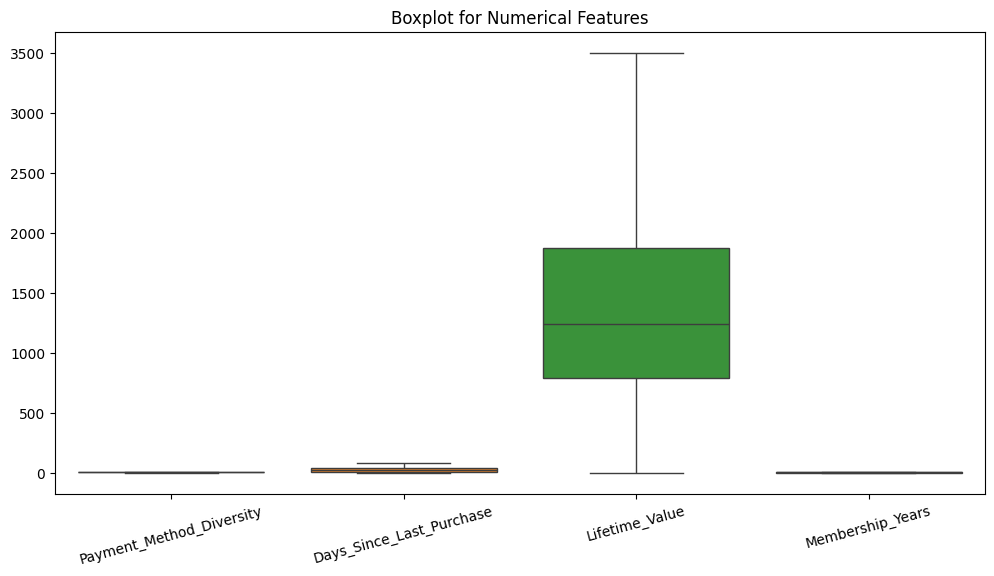

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_check = ['Payment_Method_Diversity', 'Days_Since_Last_Purchase', 'Lifetime_Value', 'Membership_Years']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title('Boxplot for Numerical Features')
plt.xticks(rotation=15)
plt.show()

In [45]:
X = df.drop("Churned", axis=1)
Y = df["Churned"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train["Gender"] = le.fit_transform(X_train["Gender"])
X_test["Gender"] = le.transform(X_test["Gender"])

X_train = pd.get_dummies(
    X_train,
    columns=["Country", "City", "Signup_Quarter"],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["Country", "City", "Signup_Quarter"],
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [47]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)

X_test_scaled = scaler.transform(X_test)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [50]:
logistic_model=LogisticRegression()
logistic_model.fit(X_train_scaled,y_train_balanced)


accuracies=cross_val_score(estimator=logistic_model,X=X_train_scaled,y=y_train_balanced,cv=5,scoring='accuracy') # handling inblance taeget
print("all Acuracy",accuracies)
print('Accuracy: {:.2f} %'.format(accuracies.mean()*100))
print('Standard Deviation: {:.2f} %'.format(accuracies.std()*100))

all Acuracy [0.64266878 0.64741561 0.91077707 0.91868847 0.92317159]
Accuracy: 80.85 %
Standard Deviation: 13.36 %


In [51]:
y_pred=logistic_model.predict(X_test_scaled)

acuuracy = accuracy_score(y_test,y_pred)
print('Accuracy test: {:.2f} %'.format(acuuracy*100))

Accuracy test: 77.04 %


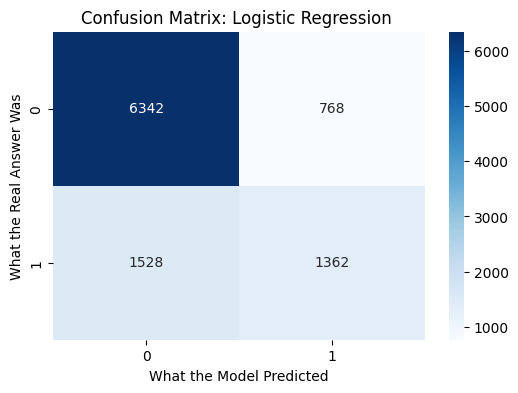

In [52]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1],
            yticklabels=[0, 1])
plt.title("Confusion Matrix: Logistic Regression ")
plt.xlabel("What the Model Predicted")
plt.ylabel("What the Real Answer Was")
plt.show()

In [53]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      7110
           1       0.64      0.47      0.54      2890

    accuracy                           0.77     10000
   macro avg       0.72      0.68      0.69     10000
weighted avg       0.76      0.77      0.76     10000



In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [55]:
Y_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy_score(y_test, Y_pred))
print("Precision:", precision_score(y_test, Y_pred))
print("Recall   :", recall_score(y_test, Y_pred))
print("F1 Score :", f1_score(y_test, Y_pred))
print("ROC AUC  :", roc_auc_score(y_test, logistic_model.predict_proba(X_test_scaled)[:, 1]))

Logistic Regression Results
----------------------------
Accuracy : 0.7704
Precision: 0.6394366197183099
Recall   : 0.471280276816609
F1 Score : 0.5426294820717131
ROC AUC  : 0.7811431825150016


In [56]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train_balanced)

SVC(random_state=42)

In [57]:
y_pred = svm_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8436
Confusion Matrix:
 [[6682  428]
 [1136 1754]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.90      7110
           1       0.80      0.61      0.69      2890

    accuracy                           0.84     10000
   macro avg       0.83      0.77      0.79     10000
weighted avg       0.84      0.84      0.84     10000



In [58]:
svm_pred = svm_model.predict(X_test_scaled)
svm_scores = svm_model.decision_function(X_test_scaled)

print("SVM (SVC) Results")
print("------------------------")
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))
print("ROC AUC  :", roc_auc_score(y_test, svm_scores))

SVM (SVC) Results
------------------------
Accuracy : 0.8436
Precision: 0.8038496791934006
Recall   : 0.6069204152249135
F1 Score : 0.6916403785488959
ROC AUC  : 0.8706991955382302


In [59]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)


In [60]:

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8796
Confusion Matrix:
 [[6498  612]
 [ 592 2298]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      7110
           1       0.79      0.80      0.79      2890

    accuracy                           0.88     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.88      0.88      0.88     10000



## Advanced Models and Hyperparameter Tuning


### 1. Random Forest — Baseline

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [62]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [63]:
rf_pred = rf_model.predict(X_test)

In [64]:
print("Random Forest Baseline Results")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
))

Random Forest Baseline Results
--------------------------------
Accuracy : 0.9041
Precision: 0.8587885544407283
Recall   : 0.7996539792387544
F1 Score : 0.8281669951621573
ROC AUC  : 0.9203458017607639


## 2. Random Forest — Cross Validation

In [65]:
rf_cv = cross_val_score(
    rf_model,
    X_train_balanced,
    y_train_balanced,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("Random Forest CV Scores:")
print(rf_cv)

print("\nMean CV F1 Score:")
print(rf_cv.mean())

Random Forest CV Scores:
[0.86042028 0.86178862 0.95308815 0.94886462 0.94790673]

Mean CV F1 Score:
0.9144136801658576


### 3. Random Forest — Hyperparameter Tuning

In [66]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

In [67]:
rf_random = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_params,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [68]:
rf_random.fit(
    X_train_balanced,
    y_train_balanced
)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, None],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

In [69]:
print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV F1 Score:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}

Best CV F1 Score:
0.8924364533729333


### 4. Tuned Random Forest — Evaluation

In [70]:
best_rf = rf_random.best_estimator_

In [71]:
best_rf_pred = best_rf.predict(X_test)

In [72]:
print("Tuned Random Forest Results")
print("----------------------------")

print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))
print("ROC AUC  :", roc_auc_score(
    y_test,
    best_rf.predict_proba(X_test)[:, 1]
))

Tuned Random Forest Results
----------------------------
Accuracy : 0.9067
Precision: 0.8647036898993664
Recall   : 0.8027681660899654
F1 Score : 0.83258568096178
ROC AUC  : 0.9213083575450532


### 5. XGBoost — Baseline

In [73]:
from xgboost import XGBClassifier

In [74]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [75]:
xgb_pred = xgb_model.predict(X_test)

In [76]:
print("XGBoost Baseline Results")
print("------------------------")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(
    y_test,
    xgb_model.predict_proba(X_test)[:, 1]
))

XGBoost Baseline Results
------------------------
Accuracy : 0.9164
Precision: 0.9033778476040848
Recall   : 0.7958477508650519
F1 Score : 0.8462104488594555
ROC AUC  : 0.9262974805211237


### 6. XGBoost — Cross Validation

In [77]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train_balanced,
    y_train_balanced,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

print("XGBoost CV Scores:")
print(xgb_cv)

print("\nMean CV F1 Score:")
print(xgb_cv.mean())

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost CV Scores:
[0.84578099 0.8488441  0.97387543 0.9772453  0.97666006]

Mean CV F1 Score:
0.9244811775975788


### 7. XGBoost — Hyperparameter Tuning

In [78]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [79]:
xgb_random = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_params,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [80]:
xgb_random.fit(
    X_train_balanced,
    y_train_balanced
)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='f1')

In [81]:
print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV F1 Score:")
print(xgb_random.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}

Best CV F1 Score:
0.9066273906084819


### 8. Tuned XGBoost — Evaluation

In [82]:
best_xgb = xgb_random.best_estimator_

In [83]:
best_xgb_pred = best_xgb.predict(X_test)

In [84]:
print("Tuned XGBoost Results")
print("---------------------")

print("Accuracy :", accuracy_score(y_test, best_xgb_pred))
print("Precision:", precision_score(y_test, best_xgb_pred))
print("Recall   :", recall_score(y_test, best_xgb_pred))
print("F1 Score :", f1_score(y_test, best_xgb_pred))
print("ROC AUC  :", roc_auc_score(
    y_test,
    best_xgb.predict_proba(X_test)[:, 1]
))

Tuned XGBoost Results
---------------------
Accuracy : 0.9217
Precision: 0.9168975069252078
Recall   : 0.8017301038062283
F1 Score : 0.8554550489200664
ROC AUC  : 0.928621659634318


 ## Model Performance Comparison

In [85]:
results = {

    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, Y_pred),
        'Precision': precision_score(y_test, Y_pred),
        'Recall': recall_score(y_test, Y_pred),
        'F1 Score': f1_score(y_test, Y_pred),
        'ROC AUC': roc_auc_score(
            y_test,
            logistic_model.predict_proba(X_test_scaled)[:, 1]
        )
    },

    'SVM': {
        'Accuracy': accuracy_score(y_test, svm_pred),
        'Precision': precision_score(y_test, svm_pred),
        'Recall': recall_score(y_test, svm_pred),
        'F1 Score': f1_score(y_test, svm_pred),
        'ROC AUC': roc_auc_score(
            y_test,
            svm_scores
        )
    },

    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        )
    },

    'Random Forest (Tuned)': {
        'Accuracy': accuracy_score(y_test, best_rf_pred),
        'Precision': precision_score(y_test, best_rf_pred),
        'Recall': recall_score(y_test, best_rf_pred),
        'F1 Score': f1_score(y_test, best_rf_pred),
        'ROC AUC': roc_auc_score(
            y_test,
            best_rf.predict_proba(X_test)[:, 1]
        )
    },

    'XGBoost (Tuned)': {
        'Accuracy': accuracy_score(y_test, best_xgb_pred),
        'Precision': precision_score(y_test, best_xgb_pred),
        'Recall': recall_score(y_test, best_xgb_pred),
        'F1 Score': f1_score(y_test, best_xgb_pred),
        'ROC AUC': roc_auc_score(
            y_test,
            best_xgb.predict_proba(X_test)[:, 1]
        )
    }
}

comparison_df = pd.DataFrame(results).T.sort_values(
    'F1 Score',
    ascending=False
)

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
XGBoost (Tuned),0.9217,0.916898,0.801730,0.855455,0.928622
Random Forest (Tuned),0.9067,0.864704,0.802768,0.832586,0.921308
Decision Tree,0.8796,0.789691,0.795156,0.792414,0.897305
SVM,0.8436,0.803850,0.606920,0.691640,0.870699
Logistic Regression,0.7704,0.639437,0.471280,0.542629,0.781143


In [86]:
best_model_name = comparison_df['F1 Score'].idxmax()

print("Best Model based on F1 Score:")
print(best_model_name)

print("\nBest Model Performance:")
print(comparison_df.loc[best_model_name])

Best Model based on F1 Score:
XGBoost (Tuned)

Best Model Performance:
Accuracy     0.921700
Precision    0.916898
Recall       0.801730
F1 Score     0.855455
ROC AUC      0.928622
Name: XGBoost (Tuned), dtype: float64


In [87]:
import plotly.graph_objects as go

models = comparison_df.index

colors = [
    '#3498db',  # Blue
    '#e74c3c',  # Red
    '#2ecc71',  # Green
    '#9b59b6',  # Purple
    '#f39c12'   # Orange
]

fig = go.Figure()

for i, model in enumerate(models):

    fig.add_trace(
        go.Bar(
            x=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
            y=[
                comparison_df.loc[model, 'Accuracy'],
                comparison_df.loc[model, 'Precision'],
                comparison_df.loc[model, 'Recall'],
                comparison_df.loc[model, 'F1 Score']
            ],
            name=model,
            marker_color=colors[i],
            hovertemplate=(
                f'Model: {model}<br>'
                'Metric: %{x}<br>'
                'Value: %{y:.4f}'
                '<extra></extra>'
            )
        )
    )

fig.update_layout(
    title="<b>📊 Model Performance Comparison</b>",
    title_x=0.5,
    xaxis_title="Metrics",
    yaxis_title="Score",
    barmode='group',
    template='plotly_white',
    height=600
)

fig.show()

In [88]:
import joblib

joblib.dump(best_xgb, "xgboost_tuned.pkl")

joblib.dump(le, "gender_encoder.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Files saved successfully!")

Files saved successfully!


In [89]:
import os

print(os.listdir())

['.config', 'xgboost_tuned.pkl', 'scaler.pkl', 'ecommerce_customer_churn_dataset.csv', 'feature_columns.pkl', 'gender_encoder.pkl', 'sample_data']


In [90]:
model = joblib.load("xgboost_tuned.pkl")

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
